<a href="https://colab.research.google.com/github/nimasabimanyu/Koding-Kecerdasan-Artifisial/blob/main/Praktikum_Analisis_Performa_Penjualan_(KKA).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('data_penjualan.csv')
df.head()

,Order_ID,CustomerID,Order_Date,Product_Category,Quantity,Price_Per_Unit,Ad_Budget,Total_Sales
0,1001,5039,2023-08-19,Books,4,1184000.0,982000.0,4736000.0
1,1002,5029,2023-08-29,Fashion,5,1733000.0,3513000.0,8665000.0
2,1003,5015,2023-02-21,Fashion,4,1767000.0,2117000.0,7068000.0
3,1004,5043,2023-04-06,Fashion,2,512000.0,4384000.0,1024000.0
4,1005,5008,2023-08-10,Home Decor,2,1820000.0,2625000.0,3640000.0


In [ ]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Order_ID          150 non-null    int64  
 1   CustomerID        150 non-null    int64  
 2   Order_Date        150 non-null    object 
 3   Product_Category  150 non-null    object 
 4   Quantity          150 non-null    int64  
 5   Price_Per_Unit    150 non-null    float64
 6   Ad_Budget         150 non-null    float64
 7   Total_Sales       143 non-null    float64
dtypes: float64(3), int64(3), object(2)
memory usage: 9.5+ KB


,0
Order_ID,0
CustomerID,0
Order_Date,0
Product_Category,0
Quantity,0
Price_Per_Unit,0
Ad_Budget,0
Total_Sales,7


In [ ]:
print(df.columns)

Index(['Order_ID', 'CustomerID', 'Order_Date', 'Product_Category', 'Quantity',
       'Price_Per_Unit', 'Ad_Budget', 'Total_Sales'],
      dtype='object')


In [ ]:
df = df[df['Price_Per_Unit'] > 0]
df['Order_Date'] = pd.to_datetime(df['Order_Date'])

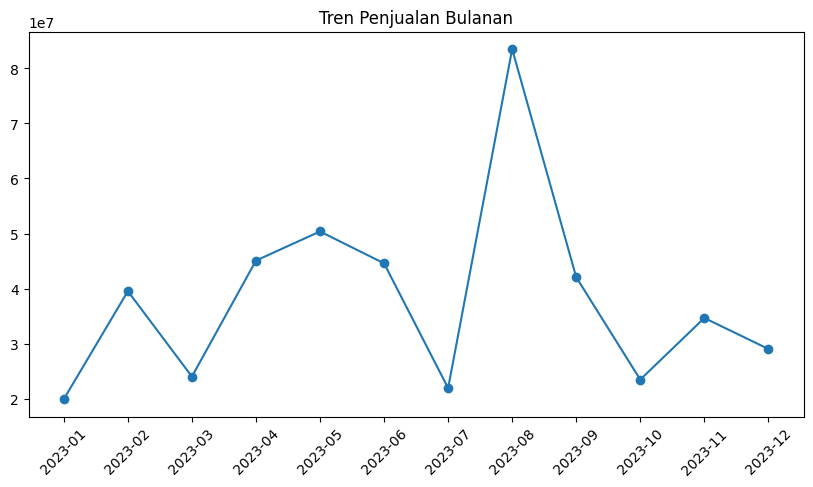

In [ ]:
df['Month'] = df['Order_Date'].dt.to_period('M').astype(str)
monthly_sales = df.groupby('Month')['Total_Sales'].sum()

plt.figure(figsize=(10,5))
plt.plot(monthly_sales.index, monthly_sales.values, marker='o')
plt.title('Tren Penjualan Bulanan')
plt.xticks(rotation=45)
plt.show()

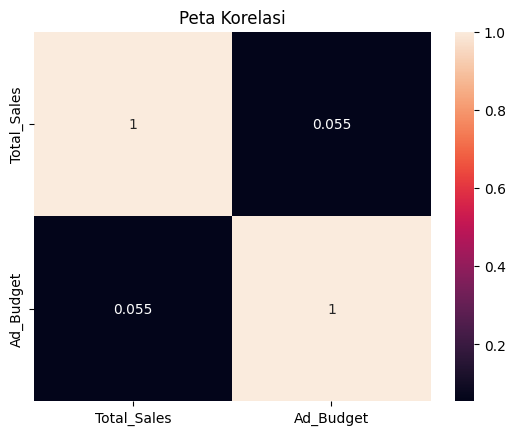

In [ ]:
correlation = df[['Total_Sales', 'Ad_Budget']].corr()

sns.heatmap(correlation, annot=True)
plt.title('Peta Korelasi')
plt.show()

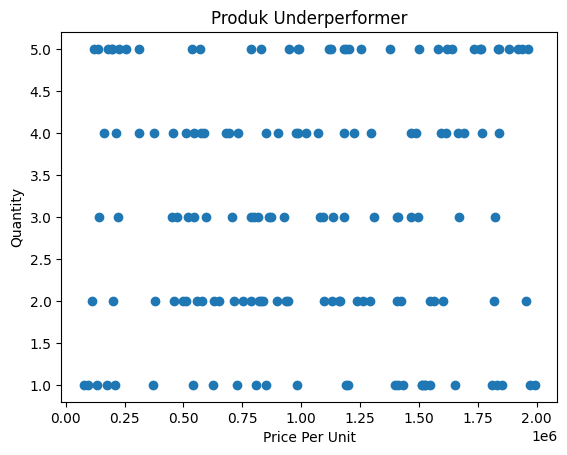

In [ ]:
plt.scatter(df['Price_Per_Unit'], df['Quantity'])
plt.xlabel('Price Per Unit')
plt.ylabel('Quantity')
plt.title('Produk Underperformer')
plt.show()

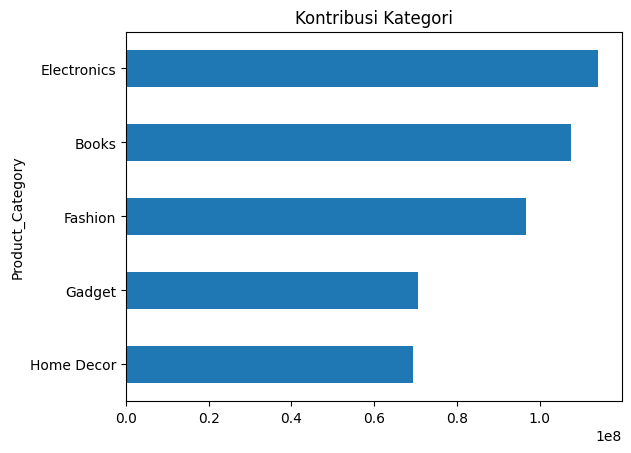

In [ ]:
category_sales = df.groupby('Product_Category')['Total_Sales'].sum()

category_sales.sort_values().plot(kind='barh')
plt.title('Kontribusi Kategori')
plt.show()

In [ ]:
median = df['Ad_Budget'].median()

high_ads = df[df['Ad_Budget'] > median]
low_ads = df[df['Ad_Budget'] <= median]

print("Rata-rata High Ads:", high_ads['Total_Sales'].mean())
print("Rata-rata Low Ads:", low_ads['Total_Sales'].mean())

Rata-rata High Ads: 3156275.362318841
Rata-rata Low Ads: 3247216.2162162163


In [ ]:
import datetime as dt

snapshot_date = df['Order_Date'].max() + dt.timedelta(days=1)

rfm = df.groupby('CustomerID').agg({
    'Order_Date': lambda x: (snapshot_date - x.max()).days,
    'Order_ID': 'count',
    'Total_Sales': 'sum'
})

rfm.columns = ['Recency', 'Frequency', 'Monetary']
rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
5001,213,4,8562000.0
5002,77,4,6931000.0
5003,118,3,9433000.0
5004,196,3,15368000.0
5005,23,2,9105000.0
